# Non-stationary Example: Separate Time-Varying Outputscale vs Lengthscale Cases

This notebook now uses **two separate synthetic examples** so each comparison isolates one mechanism:

1. Outputscale-only nonstationarity in the latent process
2. Lengthscale-only nonstationarity in the latent process

For each example, we compare only:
- Stationary Matern 5/2 baseline
- The matching time-varying variant

This avoids conflating mechanisms in a single plot and makes utility checks easier to interpret.

In [2]:
from __future__ import annotations

import math
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

repo_root = pathlib.Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from gparchitect.builders.builder import build_model_from_dsl
from gparchitect.dsl.schema import (
    FeatureGroupSpec,
    GPSpec,
    KernelSpec,
    KernelType,
    MeanFunctionType,
    MeanSpec,
    ModelClass,
    TimeVaryingSpec,
    TimeVaryingTarget,
    NoiseSpec,
    PriorDistribution,
    PriorSpec,
    CompositionType,
    ExecutionSpec,
)
from gparchitect.fitting.fitter import fit_and_validate

torch.set_default_dtype(torch.double)
torch.manual_seed(21)
np.random.seed(21)

In [3]:
# Two separate synthetic datasets:
#   (A) latent process with time-varying outputscale only
#   (B) latent process with time-varying local lengthscale only
n = 260
t = np.linspace(0.0, 1.0, n)


def build_outputscale_only_dataset(seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    trend = -0.35 + 2.05 * t + 0.10 * (t ** 2)

    # Stronger amplitude swing across time.
    outputscale_true = 0.10 + 2.20 * (t ** 1.05)
    local_lengthscale_true = np.full_like(t, 0.105)

    base_structure = (
        np.exp(-((t - 0.18) / 0.105) ** 2)
        - 1.10 * np.exp(-((t - 0.47) / 0.085) ** 2)
        + 0.95 * np.exp(-((t - 0.78) / 0.070) ** 2)
    )
    latent_clean = trend + outputscale_true * base_structure

    # Keep noise moderate so latent amplitude variation is visually dominant.
    noise_std_true = 0.02 + 0.10 * (t ** 1.1)
    noise = rng.normal(0.0, 1.0, size=n) * noise_std_true
    target = latent_clean + noise

    return pd.DataFrame(
        {
            "time": t,
            "target": target,
            "latent_clean": latent_clean,
            "trend_true": trend,
            "outputscale_true": outputscale_true,
            "local_lengthscale_true": local_lengthscale_true,
            "noise_std_true": noise_std_true,
            "example": "outputscale_only",
        }
    )


def build_lengthscale_only_dataset(seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    trend = -0.40 + 2.20 * t + 0.08 * (t ** 2)
    outputscale_true = np.full_like(t, 1.05)

    # Stronger smooth-to-rough transition over time.
    local_lengthscale_true = np.clip(0.26 - 0.22 * (t ** 1.0), 0.025, None)

    # Same centers, widths driven by local lengthscale trajectory.
    structure = (
        np.exp(-((t - 0.20) / local_lengthscale_true) ** 2)
        - 1.00 * np.exp(-((t - 0.54) / (0.70 * local_lengthscale_true + 0.008)) ** 2)
        + 0.85 * np.exp(-((t - 0.86) / (0.55 * local_lengthscale_true + 0.006)) ** 2)
    )
    latent_clean = trend + outputscale_true * structure

    noise_std_true = 0.02 + 0.10 * (t ** 1.1)
    noise = rng.normal(0.0, 1.0, size=n) * noise_std_true
    target = latent_clean + noise

    return pd.DataFrame(
        {
            "time": t,
            "target": target,
            "latent_clean": latent_clean,
            "trend_true": trend,
            "outputscale_true": outputscale_true,
            "local_lengthscale_true": local_lengthscale_true,
            "noise_std_true": noise_std_true,
            "example": "lengthscale_only",
        }
    )


df_outputscale = build_outputscale_only_dataset(seed=21)
df_lengthscale = build_lengthscale_only_dataset(seed=21)

# Keep df as an alias to the outputscale case for downstream compatibility.
df = df_outputscale.copy()
df_outputscale.head()

,time,target,latent_clean,trend_true,outputscale_true,local_lengthscale_true,noise_std_true,example
0,0.000000,-0.337531,-0.344707,-0.350000,0.100000,0.105,0.020000,outputscale_only
1,0.003861,-0.305153,-0.335702,-0.342083,0.106434,0.105,0.020221,outputscale_only
2,0.007722,-0.363062,-0.326487,-0.334164,0.113321,0.105,0.020475,outputscale_only
3,0.011583,-0.282069,-0.317052,-0.326241,0.120391,0.105,0.020742,outputscale_only
4,0.015444,-0.308368,-0.307374,-0.318316,0.127582,0.105,0.021018,outputscale_only


Notebook now contains two separate DGPs: outputscale-only and lengthscale-only.


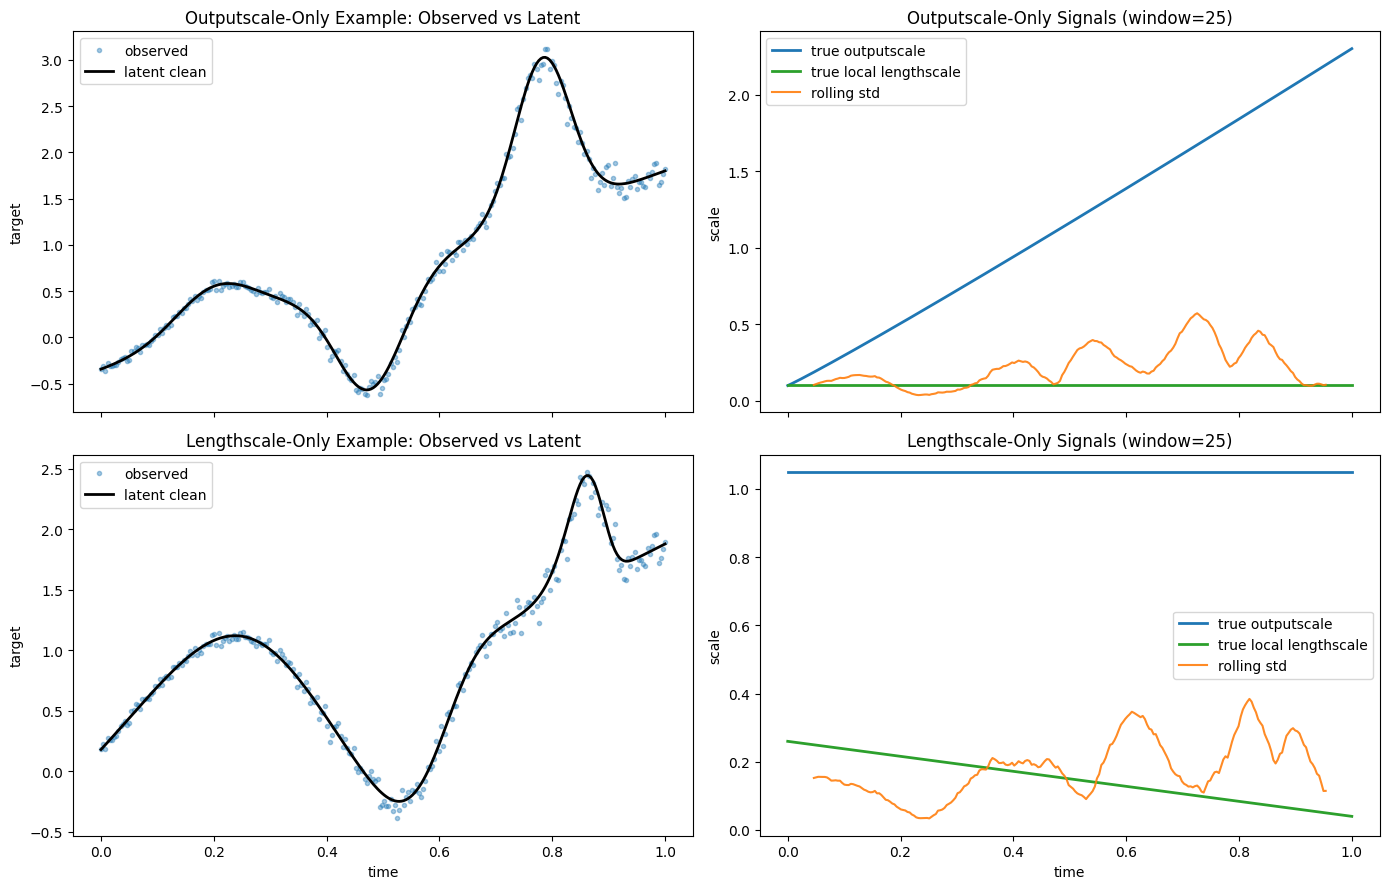

In [4]:
# EDA: visualize each mechanism separately
window = 25

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

# Outputscale-only example
rolling_std_out = df_outputscale["target"].rolling(window=window, center=True).std()
axes[0, 0].plot(df_outputscale["time"], df_outputscale["target"], ".", alpha=0.4, label="observed")
axes[0, 0].plot(df_outputscale["time"], df_outputscale["latent_clean"], color="black", linewidth=2, label="latent clean")
axes[0, 0].set_title("Outputscale-Only Example: Observed vs Latent")
axes[0, 0].set_ylabel("target")
axes[0, 0].legend(loc="best")

axes[0, 1].plot(df_outputscale["time"], df_outputscale["outputscale_true"], color="tab:blue", linewidth=2, label="true outputscale")
axes[0, 1].plot(df_outputscale["time"], df_outputscale["local_lengthscale_true"], color="tab:green", linewidth=2, label="true local lengthscale")
axes[0, 1].plot(df_outputscale["time"], rolling_std_out, color="tab:orange", alpha=0.9, label="rolling std")
axes[0, 1].set_title(f"Outputscale-Only Signals (window={window})")
axes[0, 1].set_ylabel("scale")
axes[0, 1].legend(loc="best")

# Lengthscale-only example
rolling_std_len = df_lengthscale["target"].rolling(window=window, center=True).std()
axes[1, 0].plot(df_lengthscale["time"], df_lengthscale["target"], ".", alpha=0.4, label="observed")
axes[1, 0].plot(df_lengthscale["time"], df_lengthscale["latent_clean"], color="black", linewidth=2, label="latent clean")
axes[1, 0].set_title("Lengthscale-Only Example: Observed vs Latent")
axes[1, 0].set_xlabel("time")
axes[1, 0].set_ylabel("target")
axes[1, 0].legend(loc="best")

axes[1, 1].plot(df_lengthscale["time"], df_lengthscale["outputscale_true"], color="tab:blue", linewidth=2, label="true outputscale")
axes[1, 1].plot(df_lengthscale["time"], df_lengthscale["local_lengthscale_true"], color="tab:green", linewidth=2, label="true local lengthscale")
axes[1, 1].plot(df_lengthscale["time"], rolling_std_len, color="tab:orange", alpha=0.9, label="rolling std")
axes[1, 1].set_title(f"Lengthscale-Only Signals (window={window})")
axes[1, 1].set_xlabel("time")
axes[1, 1].set_ylabel("scale")
axes[1, 1].legend(loc="best")

plt.tight_layout()
print("Notebook now contains two separate DGPs: outputscale-only and lengthscale-only.")

In [5]:
def split_tensors(dataframe: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    split_idx_local = int(0.7 * len(dataframe))
    train_df_local = dataframe.iloc[:split_idx_local].copy()
    test_df_local = dataframe.iloc[split_idx_local:].copy()
    train_X_local = torch.tensor(train_df_local[["time"]].values, dtype=torch.double)
    train_Y_local = torch.tensor(train_df_local[["target"]].values, dtype=torch.double)
    test_X_local = torch.tensor(test_df_local[["time"]].values, dtype=torch.double)
    test_Y_local = torch.tensor(test_df_local[["target"]].values, dtype=torch.double)
    return train_df_local, test_df_local, train_X_local, train_Y_local, test_X_local, test_Y_local


train_df_out, test_df_out, train_X_out, train_Y_out, test_X_out, test_Y_out = split_tensors(df_outputscale)
train_df_len, test_df_len, train_X_len, train_Y_len, test_X_len, test_Y_len = split_tensors(df_lengthscale)

# Backward-compatible aliases for downstream cells.
train_df = train_df_out
test_df = test_df_out
train_X = train_X_out
train_Y = train_Y_out
test_X = test_X_out
test_Y = test_Y_out

In [13]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def nll_gaussian(y_true: np.ndarray, mean: np.ndarray, var: np.ndarray, eps: float = 1e-8) -> float:
    var_safe = np.maximum(var, eps)
    return float(np.mean(0.5 * np.log(2.0 * np.pi * var_safe) + 0.5 * ((y_true - mean) ** 2) / var_safe))


def fit_predict(spec: GPSpec, train_X: torch.Tensor, train_Y: torch.Tensor, test_X: torch.Tensor) -> dict:
    model = build_model_from_dsl(spec, train_X, train_Y)
    fit_result = fit_and_validate(model, train_X, train_Y)
    if not fit_result.success:
        raise RuntimeError(f"Fit failed: {fit_result.error_message}")

    fitted = fit_result.model
    fitted.eval()
    fitted.likelihood.eval()

    with torch.no_grad():
        posterior = fitted.posterior(test_X)
        mean = posterior.mean.squeeze(-1).cpu().numpy()
        var = posterior.variance.squeeze(-1).cpu().numpy()

    return {"model": fitted, "mean": mean, "var": var}

In [7]:
lengthscale_prior = PriorSpec(
    distribution=PriorDistribution.LOG_NORMAL,
    params={"loc": -1.2, "scale": 0.4},
)

# Use separate outputscale priors per mechanism-specific example.
# - outputscale-only case: tighter prior to discourage runaway amplitude scaling.
# - lengthscale-only case: looser prior so lengthscale modulation remains expressive.
outputscale_prior_out = PriorSpec(
    distribution=PriorDistribution.LOG_NORMAL,
    params={"loc": -1.8, "scale": 0.12},
)
outputscale_prior_len = PriorSpec(
    distribution=PriorDistribution.LOG_NORMAL,
    params={"loc": -0.9, "scale": 0.30},
)

# Backward-compatible alias used by extended utility helper functions.
outputscale_prior = outputscale_prior_len

noise_prior = PriorSpec(
    distribution=PriorDistribution.LOG_NORMAL,
    params={"loc": -2.8, "scale": 0.5},
)

linear_mean = MeanSpec(mean_type=MeanFunctionType.LINEAR)

baseline_spec_out = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(
                kernel_type=KernelType.MATERN_52,
                lengthscale_prior=lengthscale_prior,
                outputscale_prior=outputscale_prior_out,
            ),
        )
    ],
    noise=NoiseSpec(fixed=False, prior=noise_prior),
    mean=linear_mean,
    input_dim=1,
    output_dim=1,
)

tv_outputscale_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(
                kernel_type=KernelType.MATERN_52,
                lengthscale_prior=lengthscale_prior,
                outputscale_prior=outputscale_prior_out,
                time_varying=TimeVaryingSpec(
                    target=TimeVaryingTarget.OUTPUTSCALE,
                    time_feature_index=0,
                ),
            ),
        )
    ],
    noise=NoiseSpec(fixed=False, prior=noise_prior),
    mean=linear_mean,
    input_dim=1,
    output_dim=1,
)

baseline_spec_len = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(
                kernel_type=KernelType.MATERN_52,
                lengthscale_prior=lengthscale_prior,
                outputscale_prior=outputscale_prior_len,
            ),
        )
    ],
    noise=NoiseSpec(fixed=False, prior=noise_prior),
    mean=linear_mean,
    input_dim=1,
    output_dim=1,
)

tv_lengthscale_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(
                kernel_type=KernelType.MATERN_52,
                lengthscale_prior=lengthscale_prior,
                outputscale_prior=outputscale_prior_len,
                time_varying=TimeVaryingSpec(
                    target=TimeVaryingTarget.LENGTHSCALE,
                    time_feature_index=0,
                ),
            ),
        )
    ],
    noise=NoiseSpec(fixed=False, prior=noise_prior),
    mean=linear_mean,
    input_dim=1,
    output_dim=1,
)

# Backward-compatible baseline alias.
baseline_spec = baseline_spec_out

In [14]:
# Example A: outputscale-only DGP -> baseline vs TV outputscale
baseline_out = fit_predict(baseline_spec_out, train_X_out, train_Y_out, test_X_out)
tv_out = fit_predict(tv_outputscale_spec, train_X_out, train_Y_out, test_X_out)
y_true_out = test_Y_out.squeeze(-1).cpu().numpy()

metrics_outputscale = pd.DataFrame(
    [
        {
            "model": "Matern52 baseline",
            "RMSE": rmse(y_true_out, baseline_out["mean"]),
            "MAE": mae(y_true_out, baseline_out["mean"]),
            "NLL": nll_gaussian(y_true_out, baseline_out["mean"], baseline_out["var"]),
        },
        {
            "model": "Time-varying outputscale",
            "RMSE": rmse(y_true_out, tv_out["mean"]),
            "MAE": mae(y_true_out, tv_out["mean"]),
            "NLL": nll_gaussian(y_true_out, tv_out["mean"], tv_out["var"]),
        },
    ]
).sort_values("RMSE")

# Example B: lengthscale-only DGP -> baseline vs TV lengthscale
baseline_len = fit_predict(baseline_spec_len, train_X_len, train_Y_len, test_X_len)
tv_len = fit_predict(tv_lengthscale_spec, train_X_len, train_Y_len, test_X_len)
y_true_len = test_Y_len.squeeze(-1).cpu().numpy()

metrics_lengthscale = pd.DataFrame(
    [
        {
            "model": "Matern52 baseline",
            "RMSE": rmse(y_true_len, baseline_len["mean"]),
            "MAE": mae(y_true_len, baseline_len["mean"]),
            "NLL": nll_gaussian(y_true_len, baseline_len["mean"], baseline_len["var"]),
        },
        {
            "model": "Time-varying lengthscale",
            "RMSE": rmse(y_true_len, tv_len["mean"]),
            "MAE": mae(y_true_len, tv_len["mean"]),
            "NLL": nll_gaussian(y_true_len, tv_len["mean"], tv_len["var"]),
        },
    ]
).sort_values("RMSE")

print("Outputscale-only example metrics:")
display(metrics_outputscale)
print("Lengthscale-only example metrics:")
display(metrics_lengthscale)

# Backward-compatible aliases used by later cells.
baseline = baseline_out
y_true = y_true_out
metrics = metrics_outputscale.copy()

Outputscale-only example metrics:


,model,RMSE,MAE,NLL
0,Matern52 baseline,0.671915,0.489247,8.483153
1,Time-varying outputscale,1.030985,0.870983,1.248011


Lengthscale-only example metrics:


,model,RMSE,MAE,NLL
0,Matern52 baseline,0.601787,0.493659,1.613188
1,Time-varying lengthscale,0.602530,0.489924,1.232830


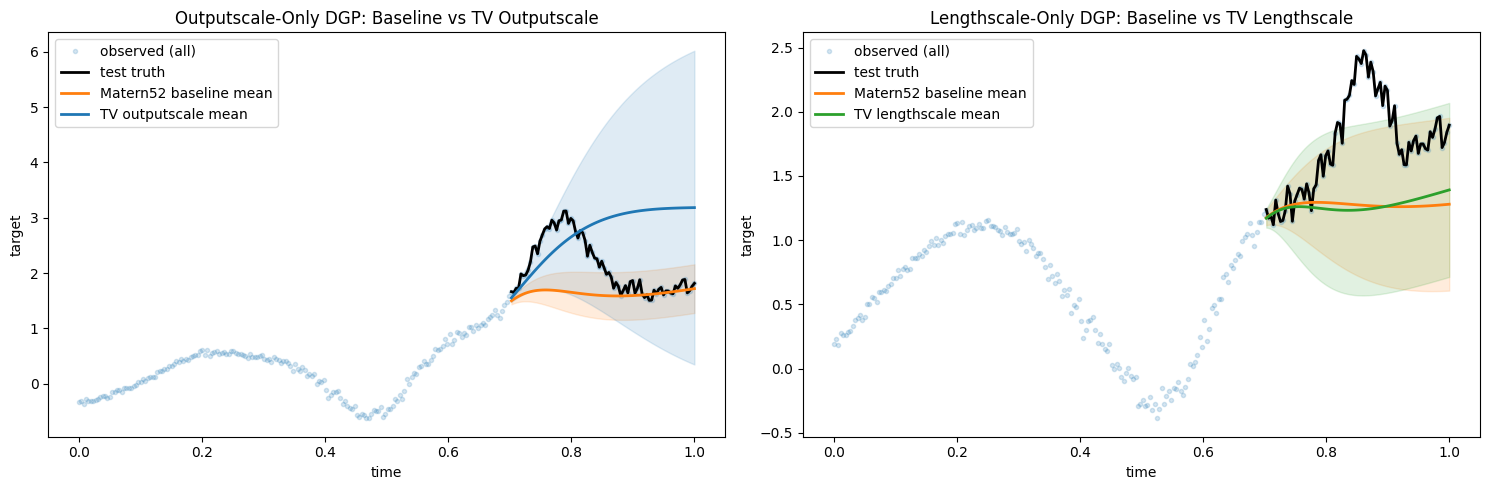

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Outputscale-only comparison: baseline vs TV outputscale
axes[0].plot(df_outputscale["time"], df_outputscale["target"], ".", alpha=0.18, label="observed (all)")
axes[0].plot(test_df_out["time"], y_true_out, color="black", linewidth=2, label="test truth")
for model_name, result_obj, color in [
    ("Matern52 baseline", baseline_out, "tab:orange"),
    ("TV outputscale", tv_out, "tab:blue"),
]:
    mean = result_obj["mean"]
    std = np.sqrt(np.maximum(result_obj["var"], 1e-9))
    x_eval = test_df_out["time"].to_numpy()
    axes[0].plot(x_eval, mean, color=color, linewidth=2, label=f"{model_name} mean")
    axes[0].fill_between(x_eval, mean - 1.96 * std, mean + 1.96 * std, color=color, alpha=0.14)
axes[0].set_title("Outputscale-Only DGP: Baseline vs TV Outputscale")
axes[0].set_xlabel("time")
axes[0].set_ylabel("target")
axes[0].legend(loc="best")

# Lengthscale-only comparison: baseline vs TV lengthscale
axes[1].plot(df_lengthscale["time"], df_lengthscale["target"], ".", alpha=0.18, label="observed (all)")
axes[1].plot(test_df_len["time"], y_true_len, color="black", linewidth=2, label="test truth")
for model_name, result_obj, color in [
    ("Matern52 baseline", baseline_len, "tab:orange"),
    ("TV lengthscale", tv_len, "tab:green"),
]:
    mean = result_obj["mean"]
    std = np.sqrt(np.maximum(result_obj["var"], 1e-9))
    x_eval = test_df_len["time"].to_numpy()
    axes[1].plot(x_eval, mean, color=color, linewidth=2, label=f"{model_name} mean")
    axes[1].fill_between(x_eval, mean - 1.96 * std, mean + 1.96 * std, color=color, alpha=0.14)
axes[1].set_title("Lengthscale-Only DGP: Baseline vs TV Lengthscale")
axes[1].set_xlabel("time")
axes[1].set_ylabel("target")
axes[1].legend(loc="best")

plt.tight_layout()

In [16]:
def get_tv_params(model):
    raw_bias = None
    raw_slope = None
    effective_bias = None
    effective_slope = None

    for name, param in model.named_parameters():
        if name.endswith("raw_tv_bias"):
            raw_bias = float(param.detach().cpu().squeeze())
        if name.endswith("raw_tv_slope"):
            raw_slope = float(param.detach().cpu().squeeze())

    if hasattr(model.covar_module, "_bounded_params"):
        with torch.no_grad():
            b_eff, s_eff = model.covar_module._bounded_params()
        effective_bias = float(b_eff.detach().cpu().squeeze())
        effective_slope = float(s_eff.detach().cpu().squeeze())

    return {
        "raw_bias": raw_bias,
        "raw_slope": raw_slope,
        "effective_bias": effective_bias,
        "effective_slope": effective_slope,
    }


print("Outputscale-only example -> TV outputscale params:", get_tv_params(tv_out["model"]))
print("Lengthscale-only example -> TV lengthscale params:", get_tv_params(tv_len["model"]))

Outputscale-only example -> TV outputscale params: {'raw_bias': 5.147801015809274, 'raw_slope': 3.8838646396890413, 'effective_bias': 3.9997297584233618, 'effective_slope': 3.9966160473216337}
Lengthscale-only example -> TV lengthscale params: {'raw_bias': 0.8463415941605473, 'raw_slope': -1.410802268470468, 'effective_bias': None, 'effective_slope': None}


## Extended Utility Checks

This section adds stronger validation of time-varying kernel utility:

1. Calibration diagnostics (coverage, PIT, reliability)
2. Multi-seed robustness summary (median and IQR)
3. Reduced-mean-mismatch variant
4. Learned modulation-function visualization

In [11]:
def normal_cdf_np(y: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    y_t = torch.tensor(y, dtype=torch.double)
    mean_t = torch.tensor(mean, dtype=torch.double)
    std_t = torch.tensor(np.maximum(std, 1e-12), dtype=torch.double)
    dist = torch.distributions.Normal(mean_t, std_t)
    return dist.cdf(y_t).cpu().numpy()


def calibration_summary(y: np.ndarray, mean: np.ndarray, var: np.ndarray) -> dict[str, float]:
    std = np.sqrt(np.maximum(var, 1e-12))
    z = np.abs(y - mean) / std
    cover_68 = float(np.mean(z <= 1.0))
    cover_95 = float(np.mean(z <= 1.959963984540054))
    avg_std = float(np.mean(std))
    return {
        "coverage_68": cover_68,
        "coverage_95": cover_95,
        "avg_std": avg_std,
    }


def summarize_with_iqr(values: np.ndarray) -> tuple[float, float, float]:
    q1, med, q3 = np.quantile(values, [0.25, 0.5, 0.75])
    return float(med), float(q1), float(q3)


def build_specs_with_shared_priors() -> tuple[GPSpec, GPSpec, GPSpec]:
    baseline = GPSpec(
        model_class=ModelClass.SINGLE_TASK_GP,
        feature_groups=[
            FeatureGroupSpec(
                name="time",
                feature_indices=[0],
                kernel=KernelSpec(
                    kernel_type=KernelType.MATERN_52,
                    lengthscale_prior=lengthscale_prior,
                    outputscale_prior=outputscale_prior,
                ),
            )
        ],
        noise=NoiseSpec(fixed=False, prior=noise_prior),
        mean=linear_mean,
        input_dim=1,
        output_dim=1,
    )

    tv_out_spec = GPSpec(
        model_class=ModelClass.SINGLE_TASK_GP,
        feature_groups=[
            FeatureGroupSpec(
                name="time",
                feature_indices=[0],
                kernel=KernelSpec(
                    kernel_type=KernelType.MATERN_52,
                    lengthscale_prior=lengthscale_prior,
                    outputscale_prior=outputscale_prior,
                    time_varying=TimeVaryingSpec(
                        target=TimeVaryingTarget.OUTPUTSCALE,
                        time_feature_index=0,
                    ),
                ),
            )
        ],
        noise=NoiseSpec(fixed=False, prior=noise_prior),
        mean=linear_mean,
        input_dim=1,
        output_dim=1,
    )

    tv_len_spec = GPSpec(
        model_class=ModelClass.SINGLE_TASK_GP,
        feature_groups=[
            FeatureGroupSpec(
                name="time",
                feature_indices=[0],
                kernel=KernelSpec(
                    kernel_type=KernelType.MATERN_52,
                    lengthscale_prior=lengthscale_prior,
                    outputscale_prior=outputscale_prior,
                    time_varying=TimeVaryingSpec(
                        target=TimeVaryingTarget.LENGTHSCALE,
                        time_feature_index=0,
                    ),
                ),
            )
        ],
        noise=NoiseSpec(fixed=False, prior=noise_prior),
        mean=linear_mean,
        input_dim=1,
        output_dim=1,
    )
    return baseline, tv_out_spec, tv_len_spec


def make_dataset(seed: int, *, reduced_mean_mismatch: bool = False) -> tuple[pd.DataFrame, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    rng = np.random.default_rng(seed)
    n_local = 260
    t_local = np.linspace(0.0, 1.0, n_local)

    if reduced_mean_mismatch:
        trend_local = -0.45 + 2.25 * t_local + 0.06 * (t_local ** 2)
    else:
        trend_local = -0.40 + 2.20 * t_local + 0.08 * (t_local ** 2)

    # Stronger outputscale and lengthscale variation to stress-test identifiability.
    outputscale_true_local = 0.10 + 2.20 * (t_local ** 1.05)
    local_lengthscale_true_local = np.clip(0.26 - 0.22 * (t_local ** 1.0), 0.025, None)

    structure_local = (
        np.exp(-((t_local - 0.20) / local_lengthscale_true_local) ** 2)
        - 1.00 * np.exp(-((t_local - 0.54) / (0.70 * local_lengthscale_true_local + 0.008)) ** 2)
        + 0.85 * np.exp(-((t_local - 0.86) / (0.55 * local_lengthscale_true_local + 0.006)) ** 2)
    )

    latent_clean_local = trend_local + outputscale_true_local * structure_local

    noise_std_local = 0.02 + 0.10 * (t_local ** 1.1)
    noise_local = rng.normal(0.0, 1.0, size=n_local) * noise_std_local
    y_local = latent_clean_local + noise_local

    local_df = pd.DataFrame(
        {
            "time": t_local,
            "target": y_local,
            "latent_clean": latent_clean_local,
            "trend_true": trend_local,
            "outputscale_true": outputscale_true_local,
            "local_lengthscale_true": local_lengthscale_true_local,
            "noise_std_true": noise_std_local,
        }
    )

    split_local = int(0.7 * n_local)
    tr_df = local_df.iloc[:split_local].copy()
    te_df = local_df.iloc[split_local:].copy()
    trX = torch.tensor(tr_df[["time"]].values, dtype=torch.double)
    trY = torch.tensor(tr_df[["target"]].values, dtype=torch.double)
    teX = torch.tensor(te_df[["time"]].values, dtype=torch.double)
    teY = torch.tensor(te_df[["target"]].values, dtype=torch.double)
    return local_df, trX, trY, teX, teY

### 1) Calibration Diagnostics

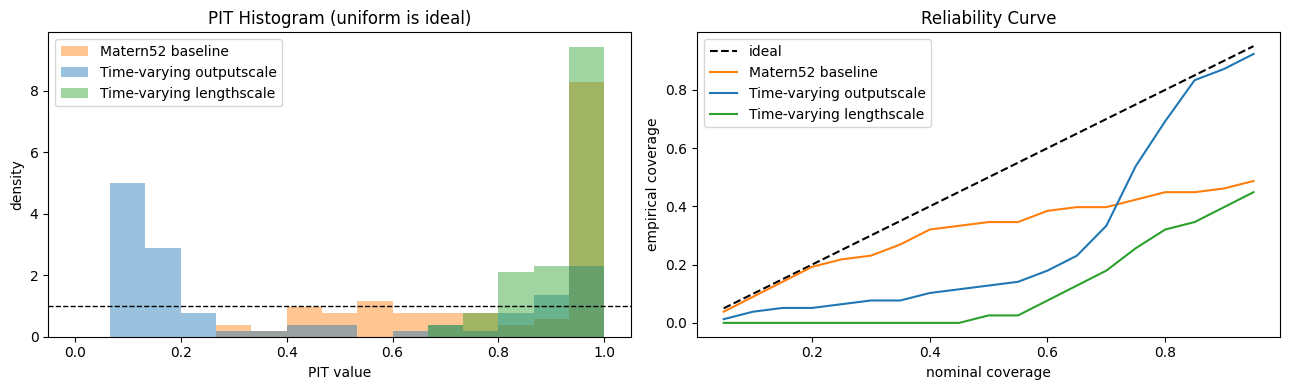

In [12]:
model_results = [
    ("Matern52 baseline", baseline, "tab:orange"),
    ("Time-varying outputscale", tv_out, "tab:blue"),
    ("Time-varying lengthscale", tv_len, "tab:green"),
]

calibration_rows = []
pit_payload = []
for model_name, model_result, color in model_results:
    cal = calibration_summary(y_true, model_result["mean"], model_result["var"])
    cal["model"] = model_name
    calibration_rows.append(cal)
    pit_vals = normal_cdf_np(y_true, model_result["mean"], np.sqrt(np.maximum(model_result["var"], 1e-12)))
    pit_payload.append((model_name, pit_vals, color))

calibration_df = pd.DataFrame(calibration_rows)[["model", "coverage_68", "coverage_95", "avg_std"]]
calibration_df

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(0.0, 1.0, 16)
for model_name, pit_vals, color in pit_payload:
    axes[0].hist(pit_vals, bins=bins, alpha=0.45, label=model_name, color=color, density=True)
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("PIT Histogram (uniform is ideal)")
axes[0].set_xlabel("PIT value")
axes[0].set_ylabel("density")
axes[0].legend(loc="best")

nominal_levels = np.linspace(0.05, 0.95, 19)
axes[1].plot(nominal_levels, nominal_levels, "k--", label="ideal")
for model_name, model_result, color in model_results:
    std = np.sqrt(np.maximum(model_result["var"], 1e-12))
    empirical = []
    for p in nominal_levels:
        z_thr = torch.distributions.Normal(0.0, 1.0).icdf(torch.tensor((1.0 + p) / 2.0)).item()
        empirical.append(float(np.mean(np.abs(y_true - model_result["mean"]) <= z_thr * std)))
    axes[1].plot(nominal_levels, empirical, color=color, label=model_name)

axes[1].set_title("Reliability Curve")
axes[1].set_xlabel("nominal coverage")
axes[1].set_ylabel("empirical coverage")
axes[1].legend(loc="best")

plt.tight_layout()

### 2) Multi-Seed Robustness (Median and IQR)